# This model is trained on (2020/01/01  to  2023/12/30) 48 month data with STATIC MASK

## Masked on geboc (detailed) depth

In [1]:
# Install the required Python library
# !pip install torchviz

# Install the Graphviz system package (Conda is recommended)
# conda install -c conda-forge python-graphviz -y

In [1]:
import torch

# Check if CUDA is available
cuda_available = torch.cuda.is_available()
print(f"Is CUDA available? {cuda_available}")

# If it is available, check how many GPUs are detected
if cuda_available:
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU Name: {torch.cuda.get_device_name(0)}")

# Check the CUDA version PyTorch was built with

print(f"PyTorch CUDA Version: {torch.version.cuda}")

Is CUDA available? True
Number of GPUs: 2
Current GPU Name: NVIDIA GeForce GTX 1080 Ti
PyTorch CUDA Version: 11.8


In [1]:
# =============================================================================
# MASTER CONFIGURATION CELL
# =============================================================================
import torch
import os

# --- Core Parameters ---
# Change this value to 24, 36, 72, etc., to test different models
LOOKBACK_HOURS = 96
# Forecast period is now 7 days (7 * 24 = 168)
FORECAST_HORIZON_HOURS = 10

# --- File Paths ---
# MODIFICATION: Updated to the new file paths you provided
RAW_DATA_PATH = r'/home/aidl/Wave-Prediction/dAtA/cmems_mod_ibi_wav_my_0.027deg_PT1H-i_multi-vars_11.00W-8.53W_38.50N-40.47N_2020-01-01-2023-12-30.nc'
STATIC_DATA_PATH = r'/home/aidl/Wave-Prediction/dAtA/cmems_GEBCO_resampled.nc'

# MODIFICATION: File paths are now dynamic to keep experiments separate
BASE_DIR = r'/home/aidl/babe_prediction'
PROCESSED_DATA_DIR = os.path.join(BASE_DIR, f'processed_data_lookback_{LOOKBACK_HOURS}_static')
# This path is now used by the ModelCheckpoint callback in Lightning
MODEL_SAVE_DIR = '/home/aidl/Wave-Prediction/models/'
MODEL_SAVE_PATH = os.path.join(MODEL_SAVE_DIR, f'convlstm_lookback_{LOOKBACK_HOURS}_forecast_{FORECAST_HORIZON_HOURS}_static.pth')


# --- Feature Engineering ---
# These are the TIME-VARYING features
VARS_TO_USE = ['VCMX','VSDmag', 'VTM10', 'VTM02', 'VTM01_WW', 'VTM01_SW1', 'VMXL', 'VHM0_WW', 'VHM0_SW1','VHM0']
TARGET_VAR = 'VCMX'
# MODIFICATION: Total input channels = 9 time-varying + 2 static (depth, mask)
INPUT_CHANNELS = len(VARS_TO_USE) + 2

# --- Training Hyperparameters ---
LEARNING_RATE = 1e-5
BATCH_SIZE = 8
EPOCHS = 50
# MODIFICATION: Early stopping patience is now a configurable parameter
EARLY_STOPPING_PATIENCE = 5

# --- System Configuration ---
NUM_WORKERS = 4  # Set to 0 if you encounter multiprocessing issues, 4+ for speed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Print a summary of the current configuration ---
print("--- Configuration Summary ---")
print(f"Lookback Period: {LOOKBACK_HOURS} hours")
print(f"Forecast Horizon: {FORECAST_HORIZON_HOURS} hours")
print(f"Input Channels: {INPUT_CHANNELS} ({len(VARS_TO_USE)} time-varying + 2 static)")
print(f"Processed Data Path: {PROCESSED_DATA_DIR}")
print(f"Model Save Directory: {MODEL_SAVE_DIR}")
print(f"Using Device: {device}")
print("---------------------------")

--- Configuration Summary ---
Lookback Period: 96 hours
Forecast Horizon: 168 hours
Input Channels: 11 (9 time-varying + 2 static)
Processed Data Path: /home/aidl/babe_prediction/processed_data_lookback_96_static
Model Save Directory: /home/aidl/Wave-Prediction/models/
Using Device: cuda
---------------------------


# STEP 1: PRE-PROCESSING SCRIPT (with Static Features)

In [3]:
# =============================================================================
# =============================================================================
import os
import pickle
import xarray as xr
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler
from tqdm.auto import tqdm
import warnings
import shutil

warnings.filterwarnings('ignore')

if os.path.exists(PROCESSED_DATA_DIR):
    print(f"Removing old processed data directory: {PROCESSED_DATA_DIR}")
    shutil.rmtree(PROCESSED_DATA_DIR)

print("\n--- Starting Full Pre-processing Workflow ---")

# Step 1: Load and Clean Data
print("\n[Step 1/5] Loading and cleaning all data...")
ds_raw = xr.open_dataset(RAW_DATA_PATH)
ds_raw['VSDmag'] = np.sqrt(ds_raw['VSDX']**2 + ds_raw['VSDY']**2)
ds_clean = ds_raw[VARS_TO_USE].astype(np.float32).fillna(0)
print("✅ Time-varying data loaded and cleaned.")

ds_static = xr.open_dataset(STATIC_DATA_PATH)
ocean_depth = ds_static['deptho'].values.astype(np.float32)
ocean_mask = ds_static['mask'].values.astype(np.float32)
print("✅ Static data loaded and cleaned from new GEBCO file.")

# Step 2: Define Data Splits
print("\n[Step 2/5] Splitting data into train, validation, and test sets...")
ds_train = ds_clean.sel(time=slice('2020-01-01', '2022-12-31'))
ds_val = ds_clean.sel(time=slice('2023-01-01', '2023-06-30'))
ds_test = ds_clean.sel(time=slice('2023-07-01', '2023-12-30'))
ds_splits = {'train': ds_train, 'val': ds_val, 'test': ds_test}
print(f"Train split: {len(ds_train.time)} time steps")
print(f"Validation split: {len(ds_val.time)} time steps")
print(f"Test split: {len(ds_test.time)} time steps")

# Step 3: Create and Save Scalers
print("\n[Step 3/5] Fitting scalers on TRAINING data only...")
scalers = {}
for var in tqdm(VARS_TO_USE, desc="Fitting Time-Varying Scalers"):
    data_to_fit = ds_train[var].values.reshape(-1, 1)
    scaler = MinMaxScaler()
    scaler.fit(data_to_fit)
    scalers[var] = scaler

print("Fitting static feature scalers...")
depth_scaler = MinMaxScaler()
depth_scaler.fit(ocean_depth.reshape(-1, 1))
scalers['ocean_depth'] = depth_scaler

os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)
scaler_path = os.path.join(PROCESSED_DATA_DIR, 'scalers_mask.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scalers, f)
print(f"✅ All scalers fitted and saved to '{scaler_path}'")

# Step 4: Scale Static Features
print("\n[Step 4/5] Scaling static features...")
scaled_depth = scalers['ocean_depth'].transform(ocean_depth.reshape(-1, 1)).reshape(ocean_depth.shape)
scaled_depth_ch = np.expand_dims(scaled_depth, axis=0)
ocean_mask_ch = np.expand_dims(ocean_mask, axis=0)
static_features_np = np.concatenate([scaled_depth_ch, ocean_mask_ch], axis=0)
print("✅ Static features scaled.")

# Step 5: Process and Save Samples
print("\n[Step 5/5] Generating and saving individual samples...")
total_window_size = LOOKBACK_HOURS + FORECAST_HORIZON_HOURS

for split_name, ds_split in ds_splits.items():
    print(f"\n--- Processing '{split_name}' split ---")
    split_dir = os.path.join(PROCESSED_DATA_DIR, split_name)
    os.makedirs(split_dir, exist_ok=True)
    
    num_sequences = len(ds_split['time']) - total_window_size
    for i in tqdm(range(num_sequences), desc=f"Saving {split_name} samples"):
        window_slice = ds_split.isel(time=slice(i, i + total_window_size))
        
        scaled_window_vars = []
        for var in VARS_TO_USE:
            data = window_slice[var].values
            scaled_data = scalers[var].transform(data.reshape(-1, 1)).reshape(data.shape)
            scaled_window_vars.append(scaled_data)
        
        scaled_window_tensor = np.stack(scaled_window_vars, axis=1)

        X_tv_np = scaled_window_tensor[:LOOKBACK_HOURS, :, :, :]
        y_np = scaled_window_tensor[LOOKBACK_HOURS:, VARS_TO_USE.index(TARGET_VAR), :, :]

        static_features_tiled = np.tile(static_features_np, (LOOKBACK_HOURS, 1, 1, 1))
        X_final_np = np.concatenate([X_tv_np, static_features_tiled], axis=1)

        X = torch.from_numpy(X_final_np.astype(np.float32))
        y = torch.from_numpy(y_np.astype(np.float32))
        
        sample_path = os.path.join(split_dir, f'sample_{i:06d}.pt')
        torch.save((X, y), sample_path)

print(f"\n\n✅ Pre-processing complete! Data is ready at: '{PROCESSED_DATA_DIR}'")

/home/aidl/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Removing old processed data directory: /home/aidl/babe_prediction/processed_data_lookback_96_static

--- Starting Full Pre-processing Workflow ---

[Step 1/5] Loading and cleaning all data...
✅ Time-varying data loaded and cleaned.
✅ Static data loaded and cleaned from new GEBCO file.

[Step 2/5] Splitting data into train, validation, and test sets...
Train split: 26304 time steps
Validation split: 4344 time steps
Test split: 4392 time steps

[Step 3/5] Fitting scalers on TRAINING data only...


Fitting Time-Varying Scalers: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:01<00:00,  5.81it/s]


Fitting static feature scalers...
✅ All scalers fitted and saved to '/home/aidl/babe_prediction/processed_data_lookback_96_static/scalers_mask.pkl'

[Step 4/5] Scaling static features...
✅ Static features scaled.

[Step 5/5] Generating and saving individual samples...

--- Processing 'train' split ---


Saving train samples: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 26040/26040 [1:19:12<00:00,  5.48it/s]



--- Processing 'val' split ---


Saving val samples: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4080/4080 [12:43<00:00,  5.34it/s]



--- Processing 'test' split ---


Saving test samples: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4128/4128 [13:09<00:00,  5.23it/s]



✅ Pre-processing complete! Data is ready at: '/home/aidl/babe_prediction/processed_data_lookback_96_static'


# STEP 2: TRAINING SCRIPT

In [2]:
# =============================================================================
# STEP 2.1: DEFINE THE LIGHTNING DATAMODULE
# =============================================================================
import pytorch_lightning as pl
import os
import glob
from torch.utils.data import Dataset, DataLoader

# Your existing Dataset class (no changes needed)
class PreprocessedWaveDataset(Dataset):
    def __init__(self, split_dir):
        self.file_paths = sorted(glob.glob(os.path.join(split_dir, '*.pt')))
    def __len__(self):
        return len(self.file_paths)
    def __getitem__(self, idx):
        return torch.load(self.file_paths[idx])

# New DataModule to handle DataLoaders
class WaveDataModule(pl.LightningDataModule):
    def __init__(self, data_dir, batch_size, num_workers):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.num_workers = num_workers

    def setup(self, stage=None):
        # Assign train/val datasets for use in dataloaders
        if stage == 'fit' or stage is None:
            self.train_dataset = PreprocessedWaveDataset(os.path.join(self.data_dir, 'train'))
            self.val_dataset = PreprocessedWaveDataset(os.path.join(self.data_dir, 'val'))
            print(f"DataModule setup complete: {len(self.train_dataset)} training samples, {len(self.val_dataset)} validation samples.")

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            pin_memory=True,
            persistent_workers=False # CHANGED
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=True,
            persistent_workers=False # CHANGED
        )

/home/aidl/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# =============================================================================
# STEP 2.2: DEFINE THE LIGHTNINGMODULE (UPDATED FOR HISTORY)
# =============================================================================
import torch
import torch.nn as nn
import pytorch_lightning as pl

# Your existing model architecture (pasted inside the LightningModule)
class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, bias):
        super(ConvLSTMCell, self).__init__(); self.input_dim, self.hidden_dim, self.kernel_size, self.bias = input_dim, hidden_dim, kernel_size, bias; self.padding = kernel_size[0] // 2; self.conv = nn.Conv2d(self.input_dim + self.hidden_dim, 4 * self.hidden_dim, self.kernel_size, padding=self.padding, bias=self.bias)
    def forward(self, x, h_c): h, c = h_c; combined = torch.cat([x, h], dim=1); cc = self.conv(combined); i, f, o, g = torch.split(cc, self.hidden_dim, dim=1); i, f, o, g = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o), torch.tanh(g); c_n = f * c + i * g; h_n = o * torch.tanh(c_n); return h_n, c_n
    def init_hidden(self, b, i, d): h, w = i; return (torch.zeros(b, self.hidden_dim, h, w, device=d), torch.zeros(b, self.hidden_dim, h, w, device=d))

class ConvLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, num_layers, batch_first=True, bias=True):
        super(ConvLSTM, self).__init__(); self.batch_first, self.num_layers = batch_first, num_layers; hidden_dims = [hidden_dim] * num_layers if isinstance(hidden_dim, int) else hidden_dim; cell_list = [];
        for i in range(self.num_layers): cur_input_dim = input_dim if i == 0 else hidden_dims[i - 1]; cell_list.append(ConvLSTMCell(cur_input_dim, hidden_dims[i], kernel_size, bias)); self.cell_list = nn.ModuleList(cell_list)
    def forward(self, x, h_c=None):
        b, s_l, _, h, w = x.size();
        if h_c is None: h_c = self._init_hidden(b, (h, w), x.device)
        cur_in = x
        for l_idx in range(self.num_layers):
            h, c = h_c[l_idx]; output_inner = []
            for t in range(s_l): h, c = self.cell_list[l_idx](cur_in[:, t, :, :, :], [h, c]); output_inner.append(h)
            cur_in = torch.stack(output_inner, dim=1)
        return cur_in, [h, c]
    def _init_hidden(self, b, i, d): return [cell.init_hidden(b, i, d) for cell in self.cell_list]

class ConvLSTMNet(nn.Module):
    def __init__(self, input_dim, forecast_horizon, hidden_dims=[64, 32], kernel_size=(3, 3)):
        super(ConvLSTMNet, self).__init__(); self.cl1 = ConvLSTM(input_dim, hidden_dims[0], kernel_size, 1, batch_first=True); self.cl2 = ConvLSTM(hidden_dims[0], hidden_dims[1], kernel_size, 1, batch_first=True); self.output_conv = nn.Conv2d(hidden_dims[1], forecast_horizon, kernel_size=(1, 1), padding='same')
    def forward(self, x_seq): l1_o, _ = self.cl1(x_seq); l2_o, _ = self.cl2(l1_o); return self.output_conv(l2_o[:, -1, :, :, :])

# New LightningModule to handle the training logic
class WavePredLightningModule(pl.LightningModule):
    def __init__(self, input_dim, forecast_horizon, lr):
        super().__init__()
        self.save_hyperparameters() # Saves args to self.hparams
        self.model = ConvLSTMNet(input_dim=input_dim, forecast_horizon=forecast_horizon)
        self.loss_fn = nn.MSELoss()
        # NEW: Initialize a dictionary to store epoch-wise metrics
        self.history = {'train_loss': [], 'val_loss': []}

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        predicted = self(x)
        loss = self.loss_fn(predicted, y)
        self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True, logger=True, sync_dist=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        predicted = self(x)
        loss = self.loss_fn(predicted, y)
        self.log('val_loss', loss, on_epoch=True, prog_bar=True, logger=True, sync_dist=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.hparams.lr)
        return optimizer

    # NEW: Hook to capture metrics at the end of the validation epoch
    def on_validation_epoch_end(self):
        # 'self.trainer.callback_metrics' holds the logged metrics for the epoch.
        # We only need the main process (rank 0) to record the history to avoid duplicates.
        if self.trainer.global_rank == 0:
            val_loss = self.trainer.callback_metrics.get('val_loss')
            if val_loss is not None:
                self.history['val_loss'].append(val_loss.item())
            
            # The 'train_loss_epoch' is automatically logged by Lightning when using on_epoch=True
            train_loss = self.trainer.callback_metrics.get('train_loss_epoch')
            if train_loss is not None:
                self.history['train_loss'].append(train_loss.item())

--- Generating Neural Network Diagram ---
✅ Network diagram saved as 'convlstm_architecture.png'


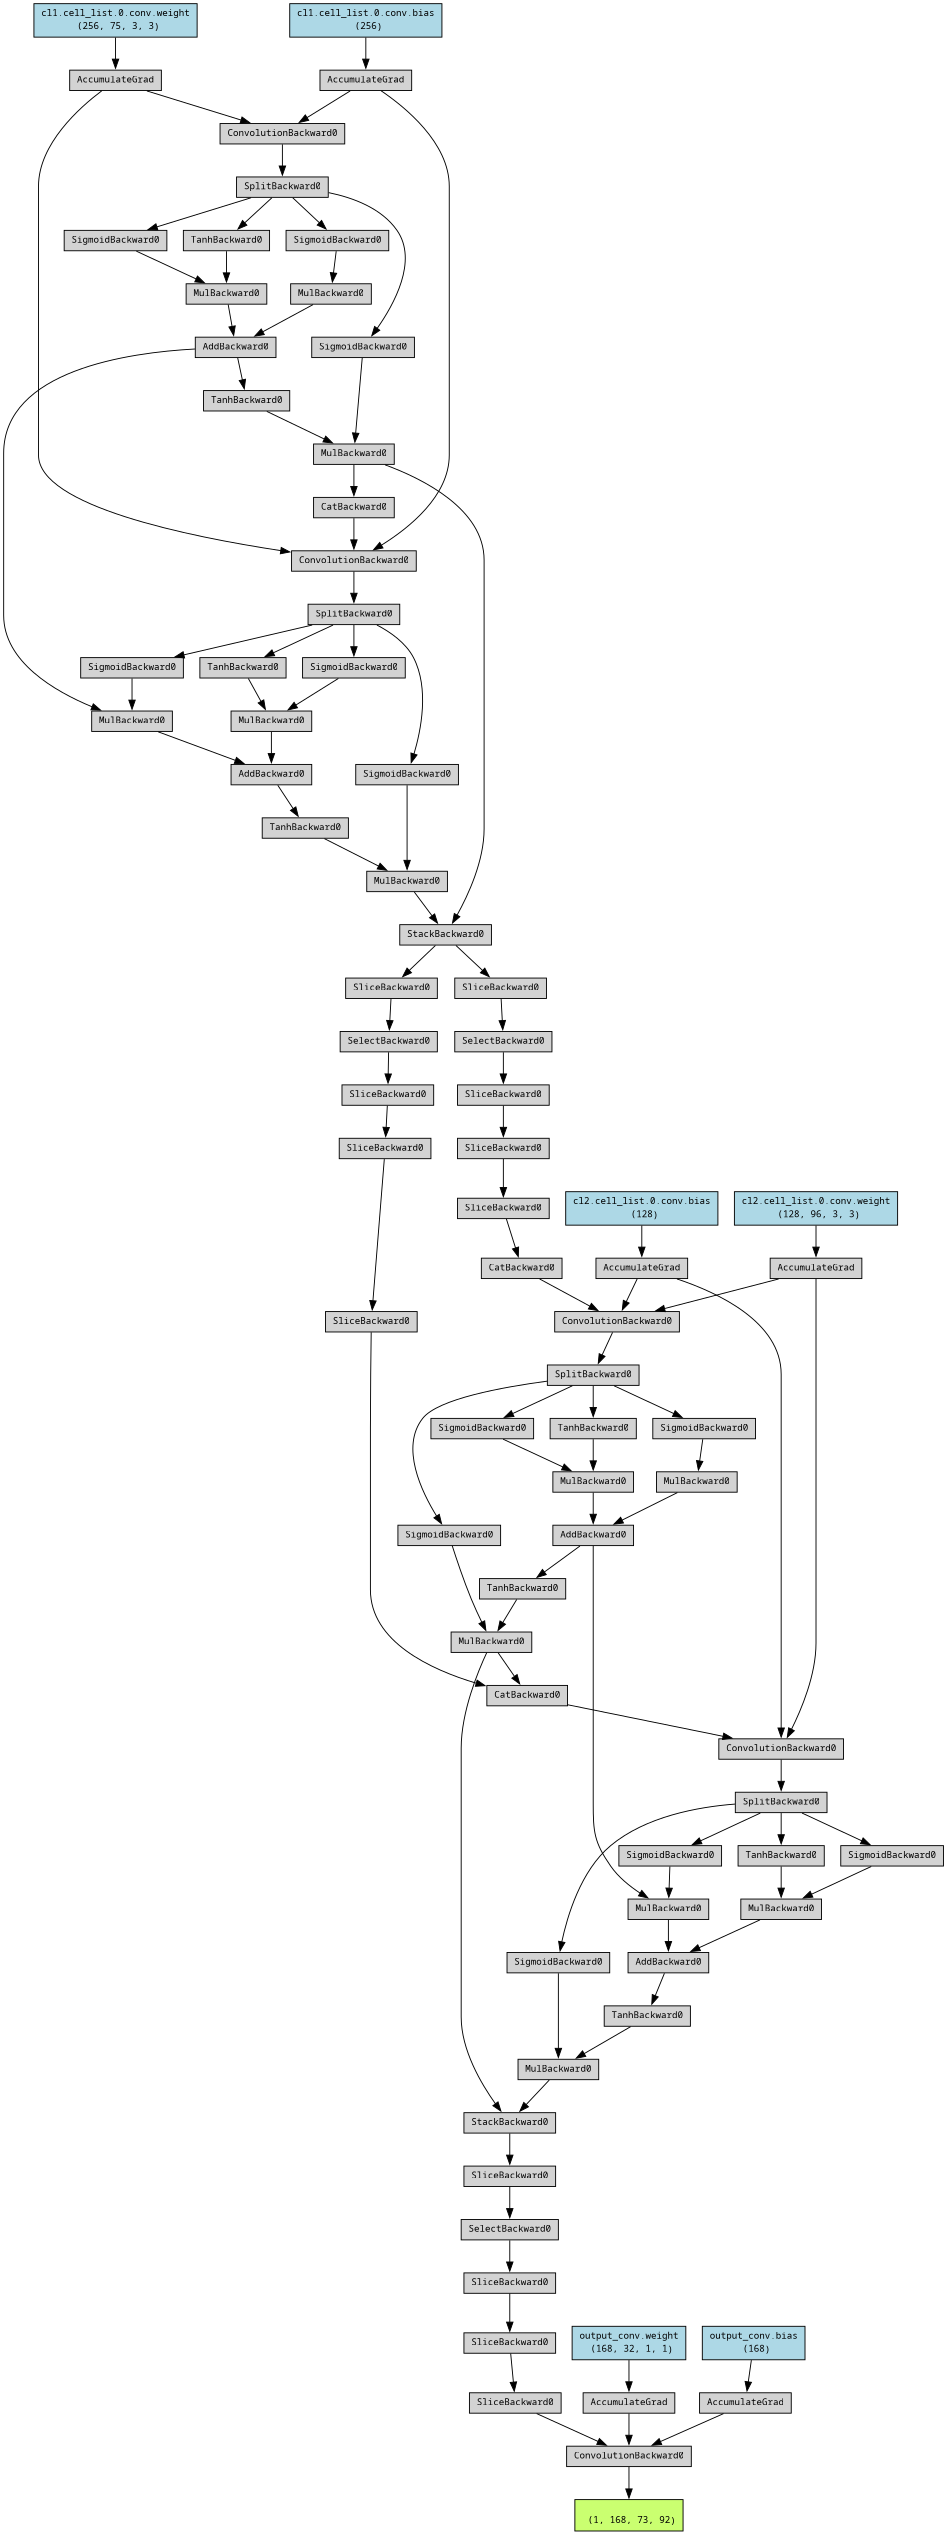

In [7]:
# =============================================================================
# OPTIONAL: VISUALIZE THE NEURAL NETWORK ARCHITECTURE
# =============================================================================
from torchviz import make_dot
from IPython.display import Image
import torch

print("--- Generating Neural Network Diagram ---")

# 1. Instantiate your model directly
# We use the ConvLSTMNet class defined in your STEP 2.2 cell
model_to_visualize = ConvLSTMNet(
    input_dim=INPUT_CHANNELS,
    forecast_horizon=FORECAST_HORIZON_HOURS
)

# 2. Create a sample input tensor with the correct shape
# The shape is (Batch, Sequence Length, Channels, Height, Width).
# IMPORTANT: We use a very short sequence length (S=2) for visualization.
# Using the full lookback period (e.g., 96) will create an enormous and unreadable graph.
# Based on your data file, H=73 and W=92 is a good estimate.
B, S, C, H, W = 1, 2, INPUT_CHANNELS, 73, 92
sample_input = torch.randn(B, S, C, H, W)

# 3. Perform a forward pass to trace the graph
output = model_to_visualize(sample_input)

# 4. Generate and save the diagram
# It will be saved as 'convlstm_architecture.png' in your current directory.
# We include model parameters and the input tensor in the graph for clarity.
graph = make_dot(
    output,
    params=dict(list(model_to_visualize.named_parameters()) + [('input', sample_input)])
)
graph.format = 'png'
graph.render('convlstm_architecture')

print("✅ Network diagram saved as 'convlstm_architecture.png'")

# 5. Display the diagram directly in the notebook
display(Image(filename='convlstm_architecture.png'))

In [9]:
# =============================================================================
# STEP 2.3: CONFIGURE AND RUN THE PYTORCH LIGHTNING TRAINER (UPDATED)
# =============================================================================
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, TQDMProgressBar # <-- ADD TQDMProgressBar
import torch
import multiprocessing
multiprocessing.set_start_method('spawn', force=True)

# This is the standard entry point guard in Python.
if __name__ == '__main__':
    # Set the start method to 'spawn' for CUDA compatibility

    # 1. Clear any cached memory from previous runs
    torch.cuda.empty_cache()

    # 2. Set up DataModule
    # Make sure NUM_WORKERS is set to a lower value (e.g., 4) in your config cell
    data_module = WaveDataModule(
        data_dir=PROCESSED_DATA_DIR,
        batch_size=4,
        num_workers=NUM_WORKERS 
    )

    # 3. Set up LightningModule
    lightning_model = WavePredLightningModule(
        input_dim=INPUT_CHANNELS,
        forecast_horizon=FORECAST_HORIZON_HOURS,
        lr=LEARNING_RATE
    )

    # 4. Configure Callbacks
    checkpoint_callback = ModelCheckpoint(
        dirpath=MODEL_SAVE_DIR,
        filename=f'convlstm-lookback{LOOKBACK_HOURS}-{{epoch:02d}}-{{val_loss:.4f}}',
        save_top_k=1,
        verbose=True,
        monitor='val_loss',
        mode='min'
    )
    
    early_stopping_callback = EarlyStopping(
        monitor='val_loss',
        patience=EARLY_STOPPING_PATIENCE,
        verbose=True,
        mode='min'
    )
    
    # NEW: Progress bar callback to create a single, clean progress bar
    progress_bar_callback = TQDMProgressBar(refresh_rate=10)

    # 5. Configure the Trainer for DDP with the new callback
    trainer = pl.Trainer(
        accelerator='gpu',
        devices=2,
        strategy='ddp_notebook',
        precision='16-mixed',
        accumulate_grad_batches=2,
        max_epochs=EPOCHS,
        # ADD the new progress bar to the callbacks list
        callbacks=[checkpoint_callback, early_stopping_callback, progress_bar_callback],
        log_every_n_steps=10
    )

    # 6. Start Training (and RESUME from the last checkpoint)
    # This path is from your last successful save at epoch 6.
    trainer.fit(lightning_model,data_module
        ,ckpt_path='/home/aidl/Wave-Prediction/models/convlstm-lookback96-epoch=06-val_loss=0.0067.ckpt'
    )

    print(f"\nTraining finished. Best model saved at: {checkpoint_callback.best_model_path}")
    best_model_path = checkpoint_callback.best_model_path

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/2
Initializing distributed: GLOBAL_RANK: 1, MEMBER: 2/2
----------------------------------------------------------------------------------------------------
distributed_backend=nccl
All distributed processes registered. Starting with 2 processes
----------------------------------------------------------------------------------------------------

2025-10-14 11:44:54.637291: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760422494.661434  357796 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760422494.668927  357796 cuda_blas.cc:1418

DataModule setup complete: 26040 training samples, 4080 validation samples.


/home/aidl/anaconda3/envs/gpu-env/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /home/aidl/Wave-Prediction/models exists and is not empty.


DataModule setup complete: 26040 training samples, 4080 validation samples.


Restoring states from the checkpoint path at /home/aidl/Wave-Prediction/models/convlstm-lookback96-epoch=06-val_loss=0.0067.ckpt
LOCAL_RANK: 1 - CUDA_VISIBLE_DEVICES: [0,1]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/home/aidl/anaconda3/envs/gpu-env/lib/python3.10/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name    | Type        | Params | Mode 
------------------------------------------------
0 | model   | ConvLSTMNet | 289 K  | train
1 | loss_fn | MSELoss     | 0      | train
------------------------------------------------
289 K     Trainable params
0         Non-trainable params
289 K     Total params
1.157     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode
Restored all states from the checkpoint at /home/aidl/Wave-Prediction/models/convlstm-lookback96-epoch=0

...

Epoch 13: 100%|████████████████████████████████████████████████████████████████████████████████| 3255/3255 [3:04:18<00:00,  0.29it/s, v_num=7, train_loss_step=0.00864, val_loss=0.00672, train_loss_epoch=0.00706]
Validation: |                                                                                                                                                                                | 0/? [00:00<?, ?it/s]
Validation: |                                                                                                                                                                                | 0/? [00:00<?, ?it/s]
Epoch 13: 100%|████████████████████████████████████████████████████████████████████████████████| 3255/3255 [3:18:19<00:00,  0.27it/s, v_num=7, train_loss_step=0.00864, val_loss=0.00666, train_loss_epoch=0.00701]

Epoch 13, global step 22792: 'val_loss' was not in top 1


Epoch 14: 100%|██████████████████████████████████████████████████████████████████████████████████| 3255/3255 [3:04:11<00:00,  0.29it/s, v_num=7, train_loss_step=0.015, val_loss=0.00666, train_loss_epoch=0.00701]
Validation: |                                                                                                                                                                                | 0/? [00:00<?, ?it/s]
Validation: |                                                                                                                                                                                | 0/? [00:00<?, ?it/s]
Epoch 14: 100%|██████████████████████████████████████████████████████████████████████████████████| 3255/3255 [3:18:13<00:00,  0.27it/s, v_num=7, train_loss_step=0.015, val_loss=0.00675, train_loss_epoch=0.00695]

[rank: 0] Monitored metric val_loss did not improve in the last 5 records. Best score: 0.007. Signaling Trainer to stop.
[rank: 1] Monitored metric val_loss did not improve in the last 5 records. Best score: 0.007. Signaling Trainer to stop.
Epoch 14, global step 24420: 'val_loss' was not in top 1


Epoch 14: 100%|██████████████████████████████████████████████████████████████████████████████████| 3255/3255 [3:18:13<00:00,  0.27it/s, v_num=7, train_loss_step=0.015, val_loss=0.00675, train_loss_epoch=0.00695]

Training finished. Best model saved at: /home/aidl/Wave-Prediction/models/convlstm-lookback96-epoch=09-val_loss=0.0066.ckpt


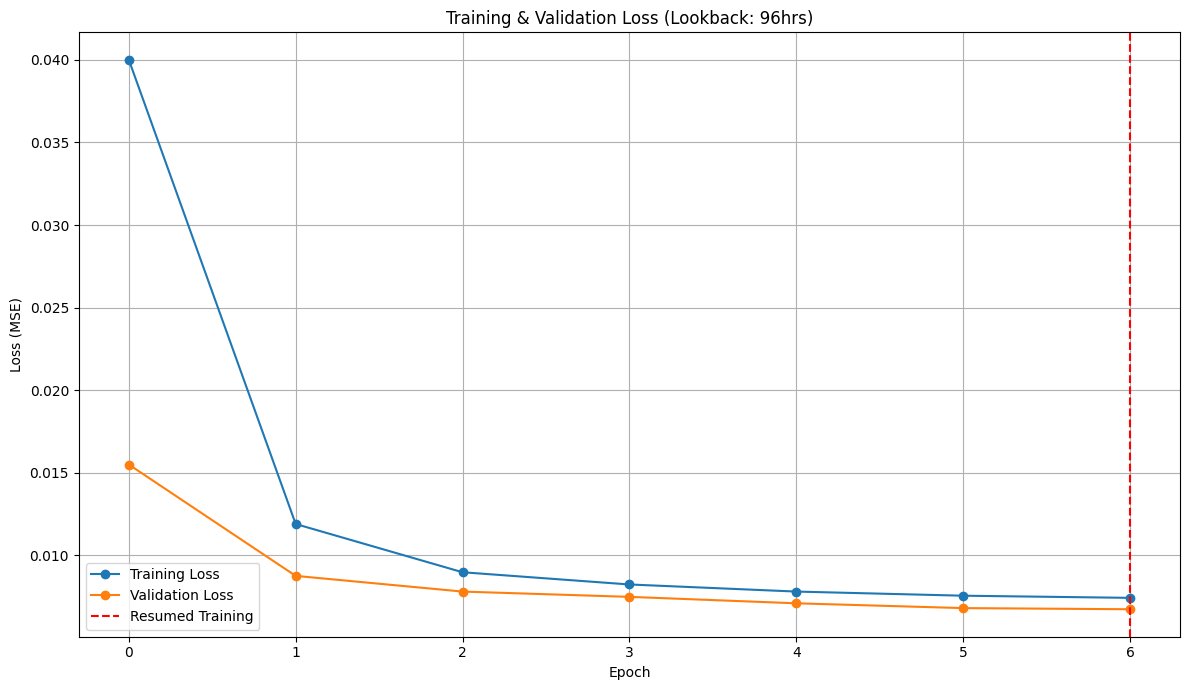

✅ Training history plot saved to 'training_history_lookback_96.png'


In [10]:
# =============================================================================
# NEW CELL: STEP 2.4 - PLOT TRAINING HISTORY
# =============================================================================
import matplotlib.pyplot as plt

# The history dictionary is now an attribute of your trained LightningModule
history = lightning_model.history

# Since resuming from a checkpoint doesn't save the old history, we manually
# add the data from the previous run to the plot for a complete picture.
# Data from your log for epochs 0-6:
previous_epochs = {
    'train_loss': [0.040, 0.0119, 0.00898, 0.00824, 0.00781, 0.00756, 0.00743],
    'val_loss': [0.0155, 0.00876, 0.00781, 0.00749, 0.0071, 0.00681, 0.00674]
}

# Combine the history from the previous run and the new run
full_history = {
    'train_loss': previous_epochs['train_loss'] + history['train_loss'],
    'val_loss': previous_epochs['val_loss'] + history['val_loss']
}


plt.figure(figsize=(12, 7))
plt.plot(full_history['train_loss'], label='Training Loss', marker='o')
plt.plot(full_history['val_loss'], label='Validation Loss', marker='o')

# Add a vertical line to show where training resumed
plt.axvline(x=len(previous_epochs['train_loss'])-1, color='r', linestyle='--', label='Resumed Training')

plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title(f'Training & Validation Loss (Lookback: {LOOKBACK_HOURS}hrs)')
plt.legend()
plt.grid(True)
plt.xticks(range(len(full_history['train_loss']))) # Ensure integer ticks for epochs
plt.tight_layout()
plt.savefig(f'training_history_lookback_{LOOKBACK_HOURS}.png', dpi=300)
plt.show()

print(f"✅ Training history plot saved to 'training_history_lookback_{LOOKBACK_HOURS}.png'")

# STEP 3: EVALUATION AND VISUALIZATION SCRIPT

In [2]:
best_model_path = '/home/aidl/Wave-Prediction/models/convlstm-lookback96-epoch=09-val_loss=0.0066.ckpt'

In [3]:
# =============================================================================
# STEP 3: EVALUATION AND METRICS CALCULATION (MEMORY-EFFICIENT)
# =============================================================================
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import numpy as np
from tqdm.auto import tqdm
import os
import pickle
import glob
from torch.utils.data import Dataset, DataLoader
from collections import OrderedDict

print("--- Starting Final Evaluation on the Test Set ---\n")

# --- Define Classes (Copied here to make the cell self-contained) ---
class PreprocessedWaveDataset(Dataset):
    def __init__(self, split_dir):
        self.file_paths = sorted(glob.glob(os.path.join(split_dir, '*.pt')))
    def __len__(self):
        return len(self.file_paths)
    def __getitem__(self, idx):
        return torch.load(self.file_paths[idx])

# Corrected Model Definitions
class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, bias):
        super(ConvLSTMCell, self).__init__(); self.input_dim, self.hidden_dim, self.kernel_size, self.bias = input_dim, hidden_dim, kernel_size, bias; self.padding = kernel_size[0] // 2; self.conv = nn.Conv2d(self.input_dim + self.hidden_dim, 4 * self.hidden_dim, self.kernel_size, padding=self.padding, bias=self.bias)
    def forward(self, x, h_c): h, c = h_c; combined = torch.cat([x, h], dim=1); cc = self.conv(combined); i, f, o, g = torch.split(cc, self.hidden_dim, dim=1); i, f, o, g = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o), torch.tanh(g); c_n = f * c + i * g; h_n = o * torch.tanh(c_n); return h_n, c_n

class ConvLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, num_layers, batch_first=True, bias=True):
        super(ConvLSTM, self).__init__(); self.batch_first, self.num_layers = batch_first, num_layers; hidden_dims = [hidden_dim] * num_layers if isinstance(hidden_dim, int) else hidden_dim; cell_list = [];
        for i in range(self.num_layers): cur_input_dim = input_dim if i == 0 else hidden_dims[i - 1]; cell_list.append(ConvLSTMCell(cur_input_dim, hidden_dims[i], kernel_size, bias)); self.cell_list = nn.ModuleList(cell_list)
    def forward(self, x, h_c=None):
        b, s_l, _, h, w = x.size();
        if h_c is None: h_c = [(torch.zeros(b, cell.hidden_dim, h, w, device=x.device), torch.zeros(b, cell.hidden_dim, h, w, device=x.device)) for cell in self.cell_list]
        cur_in = x
        for l_idx in range(self.num_layers):
            h, c = h_c[l_idx]; output_inner = []
            for t in range(s_l): h, c = self.cell_list[l_idx](cur_in[:, t, :, :, :], [h, c]); output_inner.append(h)
            cur_in = torch.stack(output_inner, dim=1)
        return cur_in, [h, c]

class ConvLSTMNet(nn.Module):
    def __init__(self, input_dim, forecast_horizon, hidden_dims=[64, 32], kernel_size=(3, 3)):
        super(ConvLSTMNet, self).__init__(); self.cl1 = ConvLSTM(input_dim, hidden_dims[0], kernel_size, 1, batch_first=True); self.cl2 = ConvLSTM(hidden_dims[0], hidden_dims[1], kernel_size, 1, batch_first=True); self.output_conv = nn.Conv2d(hidden_dims[1], forecast_horizon, kernel_size=(1, 1), padding='same')
    def forward(self, x_seq): l1_o, _ = self.cl1(x_seq); l2_o, _ = self.cl2(l1_o); return self.output_conv(l2_o[:, -1, :, :, :])


# --- Load Model and Prepare Test Loader ---
try:
    scaler_path = os.path.join(PROCESSED_DATA_DIR, 'scalers_mask.pkl')
    with open(scaler_path, 'rb') as f:
        scalers = pickle.load(f)
    print("✅ Scalers loaded successfully.")
except FileNotFoundError:
    raise SystemExit(f"❌ ERROR: Scalers file not found for lookback={LOOKBACK_HOURS}.")

test_dir = os.path.join(PROCESSED_DATA_DIR, 'test')
test_dataset = PreprocessedWaveDataset(test_dir)
# MODIFIED: Reduced num_workers to 2 to conserve RAM during evaluation
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=2)
print("✅ Test data loader prepared.")

# Load the model from the Lightning checkpoint
try:
    print(f"Loading weights from: {best_model_path}")
    checkpoint = torch.load(best_model_path, map_location=device)
    new_state_dict = OrderedDict()
    for k, v in checkpoint['state_dict'].items():
        if k.startswith('model.'):
            new_state_dict[k[6:]] = v
        else:
            new_state_dict[k] = v
            
    model = ConvLSTMNet(input_dim=INPUT_CHANNELS, forecast_horizon=FORECAST_HORIZON_HOURS)
    model.load_state_dict(new_state_dict)

except NameError:
     raise SystemExit(f"❌ ERROR: 'best_model_path' not found. Please ensure the training cell ran successfully.")
except FileNotFoundError:
    raise SystemExit(f"❌ ERROR: Model file not found at '{best_model_path}'.")

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs for evaluation.")
    model = nn.DataParallel(model)
model.to(device)
model.eval()
print("✅ Best model loaded and ready for evaluation.")

# --- MODIFIED Memory-Efficient Evaluation Function ---
def evaluate_model_ram_efficient(model, test_loader, device, scalers, target_var, forecast_horizon):
    model.eval()
    
    # For visualization of the first 2 samples
    vis_data = {'predictions': [], 'targets': []}
    
    # For scatter plot data (collecting a small sample)
    scatter_preds, scatter_targets = [], []
    
    # For metrics (running sums)
    total_sse = 0.0
    total_sae = 0.0
    total_pixels = 0
    hourly_sse = np.zeros(forecast_horizon, dtype=np.float64)
    hourly_sae = np.zeros(forecast_horizon, dtype=np.float64)

    print("\n--- Generating predictions and calculating errors iteratively... ---\n")
    with torch.no_grad():
        for X, y in tqdm(test_loader, desc="Evaluating Test Set"):
            X, y = X.to(device), y.to(device)
            predictions_scaled = model(X)

            target_scaler = scalers[target_var]
            
            pred_original = target_scaler.inverse_transform(predictions_scaled.cpu().numpy().reshape(-1, 1)).reshape(predictions_scaled.shape)
            target_original = target_scaler.inverse_transform(y.cpu().numpy().reshape(-1, 1)).reshape(y.shape)

            # Store first 2 full samples for map/timeseries visualization
            if len(vis_data['predictions']) < 2:
                vis_data['predictions'].append(pred_original[0])
                vis_data['targets'].append(target_original[0])
            
            # Collect a small random sample (e.g., 500 points) from each batch for the scatter plot
            flat_preds = pred_original.flatten()
            flat_targets = target_original.flatten()
            sample_indices = np.random.choice(len(flat_preds), min(len(flat_preds), 500), replace=False)
            scatter_preds.append(flat_preds[sample_indices])
            scatter_targets.append(flat_targets[sample_indices])
            
            # --- Iterative Metric Calculation ---
            sq_error = (pred_original - target_original) ** 2
            abs_error = np.abs(pred_original - target_original)

            total_sse += np.sum(sq_error)
            total_sae += np.sum(abs_error)
            total_pixels += sq_error.size
            
            hourly_sse += np.sum(sq_error, axis=(0, 2, 3))
            hourly_sae += np.sum(abs_error, axis=(0, 2, 3))

    num_spatial_points = pred_original.shape[2] * pred_original.shape[3]
    num_test_examples = len(test_loader.dataset)
    total_pixels_per_hour = num_spatial_points * num_test_examples
    
    overall_rmse = np.sqrt(total_sse / total_pixels)
    overall_mae = total_sae / total_pixels
    hourly_rmse = np.sqrt(hourly_sse / total_pixels_per_hour)
    hourly_mae = hourly_sae / total_pixels_per_hour

    print(f"\n📊 Overall Test Results (all {forecast_horizon} hours):")
    print(f"  Overall RMSE: {overall_rmse:.4f}")
    print(f"  Overall MAE:  {overall_mae:.4f}")

    return vis_data, hourly_rmse, hourly_mae, np.concatenate(scatter_preds), np.concatenate(scatter_targets)


# --- Run Evaluation and Store Results for Plotting ---
vis_data, hourly_rmse, hourly_mae, all_preds_flat, all_targets_flat = evaluate_model_ram_efficient(
    model, test_loader, device, scalers, TARGET_VAR, FORECAST_HORIZON_HOURS
)

print("\n✅ Metrics calculated. Data is ready for plotting in the next cell.")

--- Starting Final Evaluation on the Test Set ---

✅ Scalers loaded successfully.
✅ Test data loader prepared.
Loading weights from: /home/aidl/Wave-Prediction/models/convlstm-lookback96-epoch=09-val_loss=0.0066.ckpt
Using 2 GPUs for evaluation.
✅ Best model loaded and ready for evaluation.

--- Generating predictions and calculating errors iteratively... ---



Evaluating Test Set: 100%|██████████████████| 1032/1032 [15:08<00:00,  1.14it/s]



📊 Overall Test Results (all 168 hours):
  Overall RMSE: 1.5954
  Overall MAE:  1.0323

✅ Metrics calculated. Data is ready for plotting in the next cell.



--- Generating Visualization: Spatially-Average Time Series ---


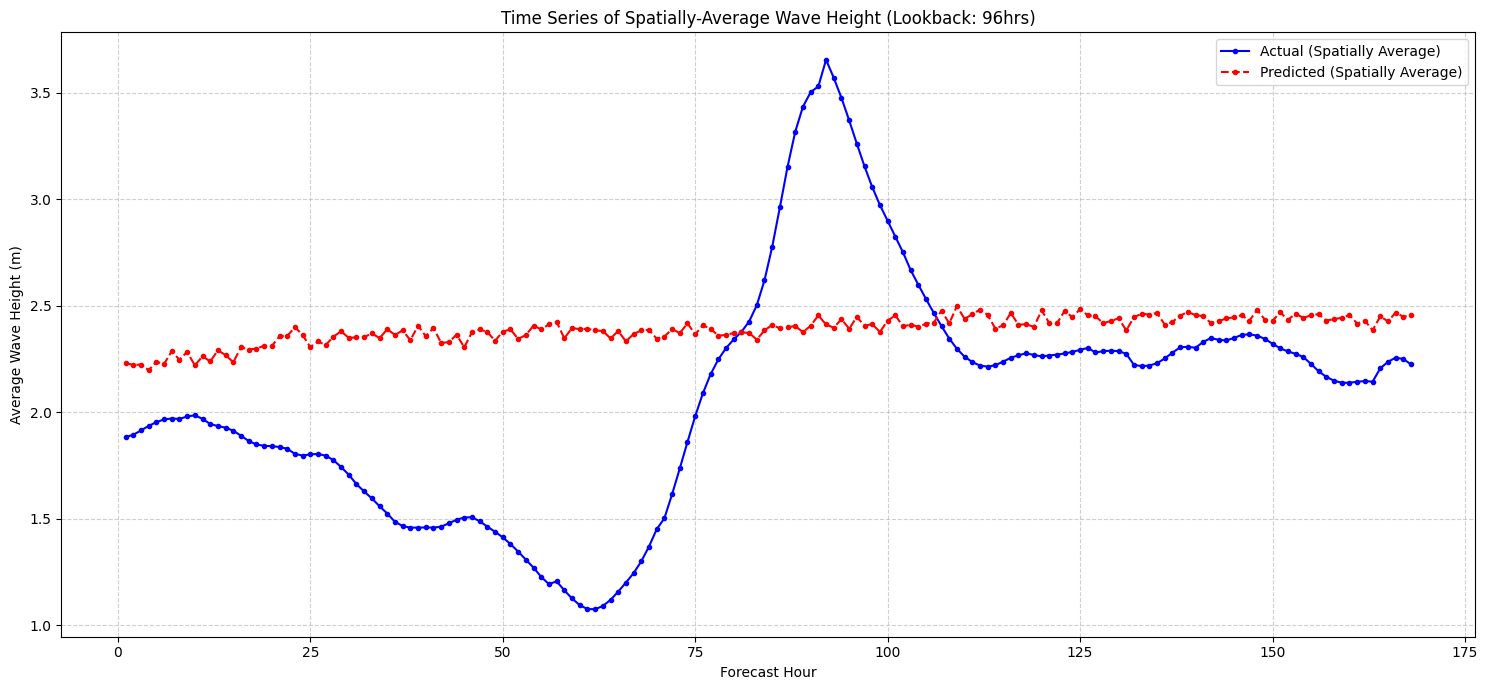


--- Generating Visualization: Spatially-Maximum Time Series ---


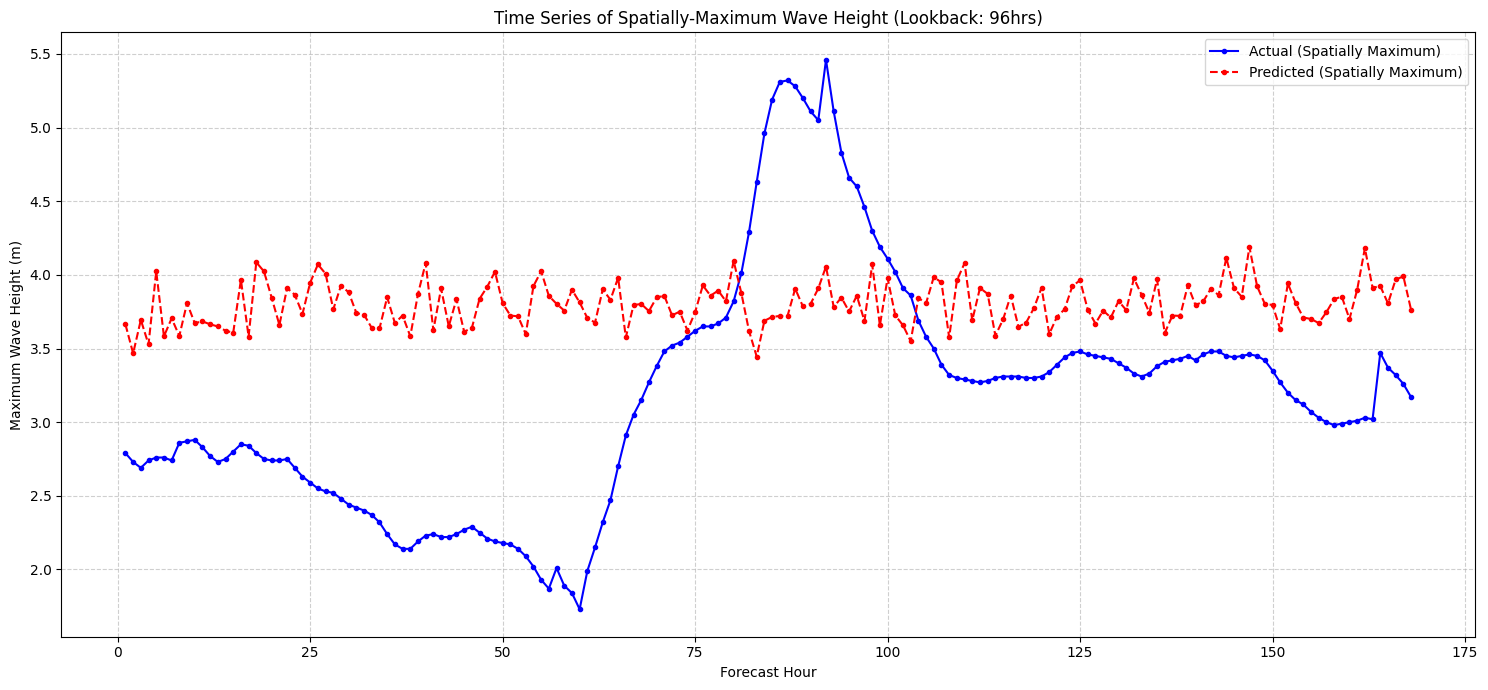


--- Generating Visualization: Average Error per Forecast Hour ---


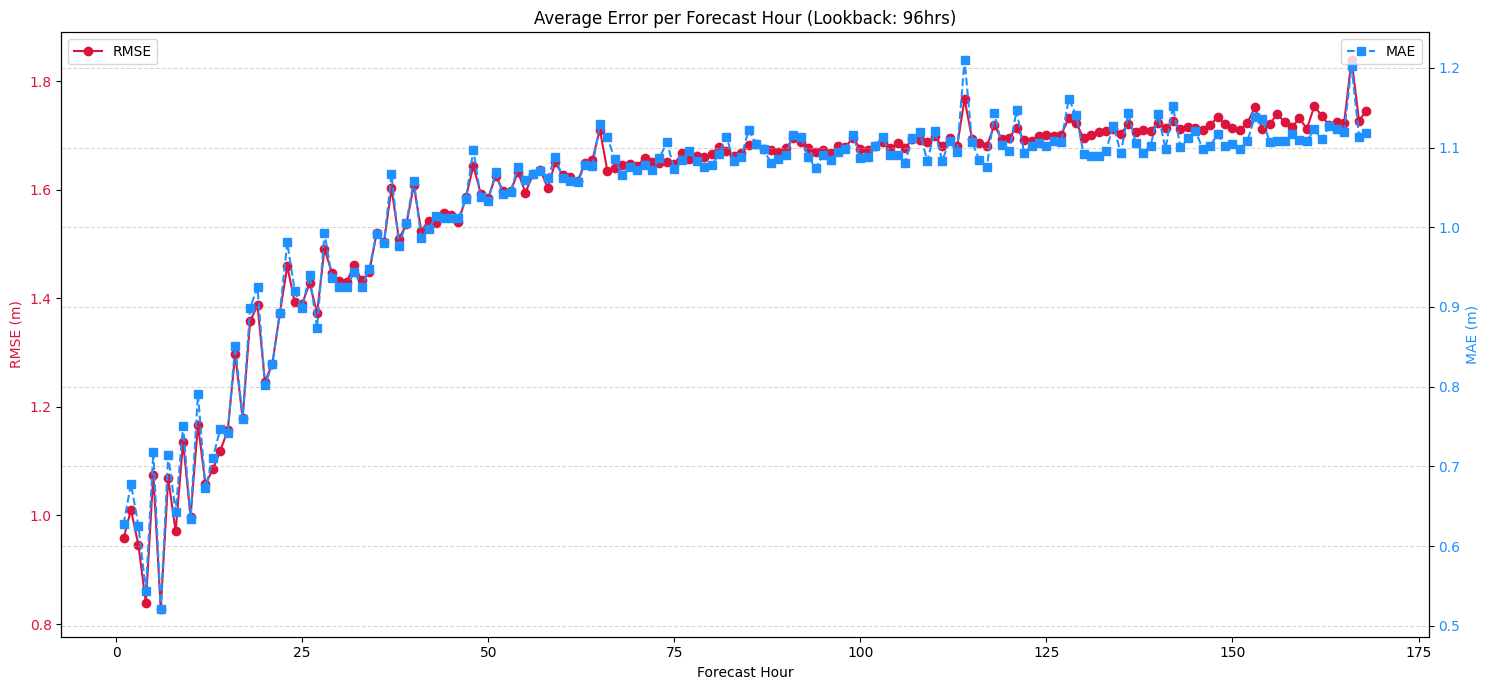


--- Generating Visualization: Comparison Maps ---


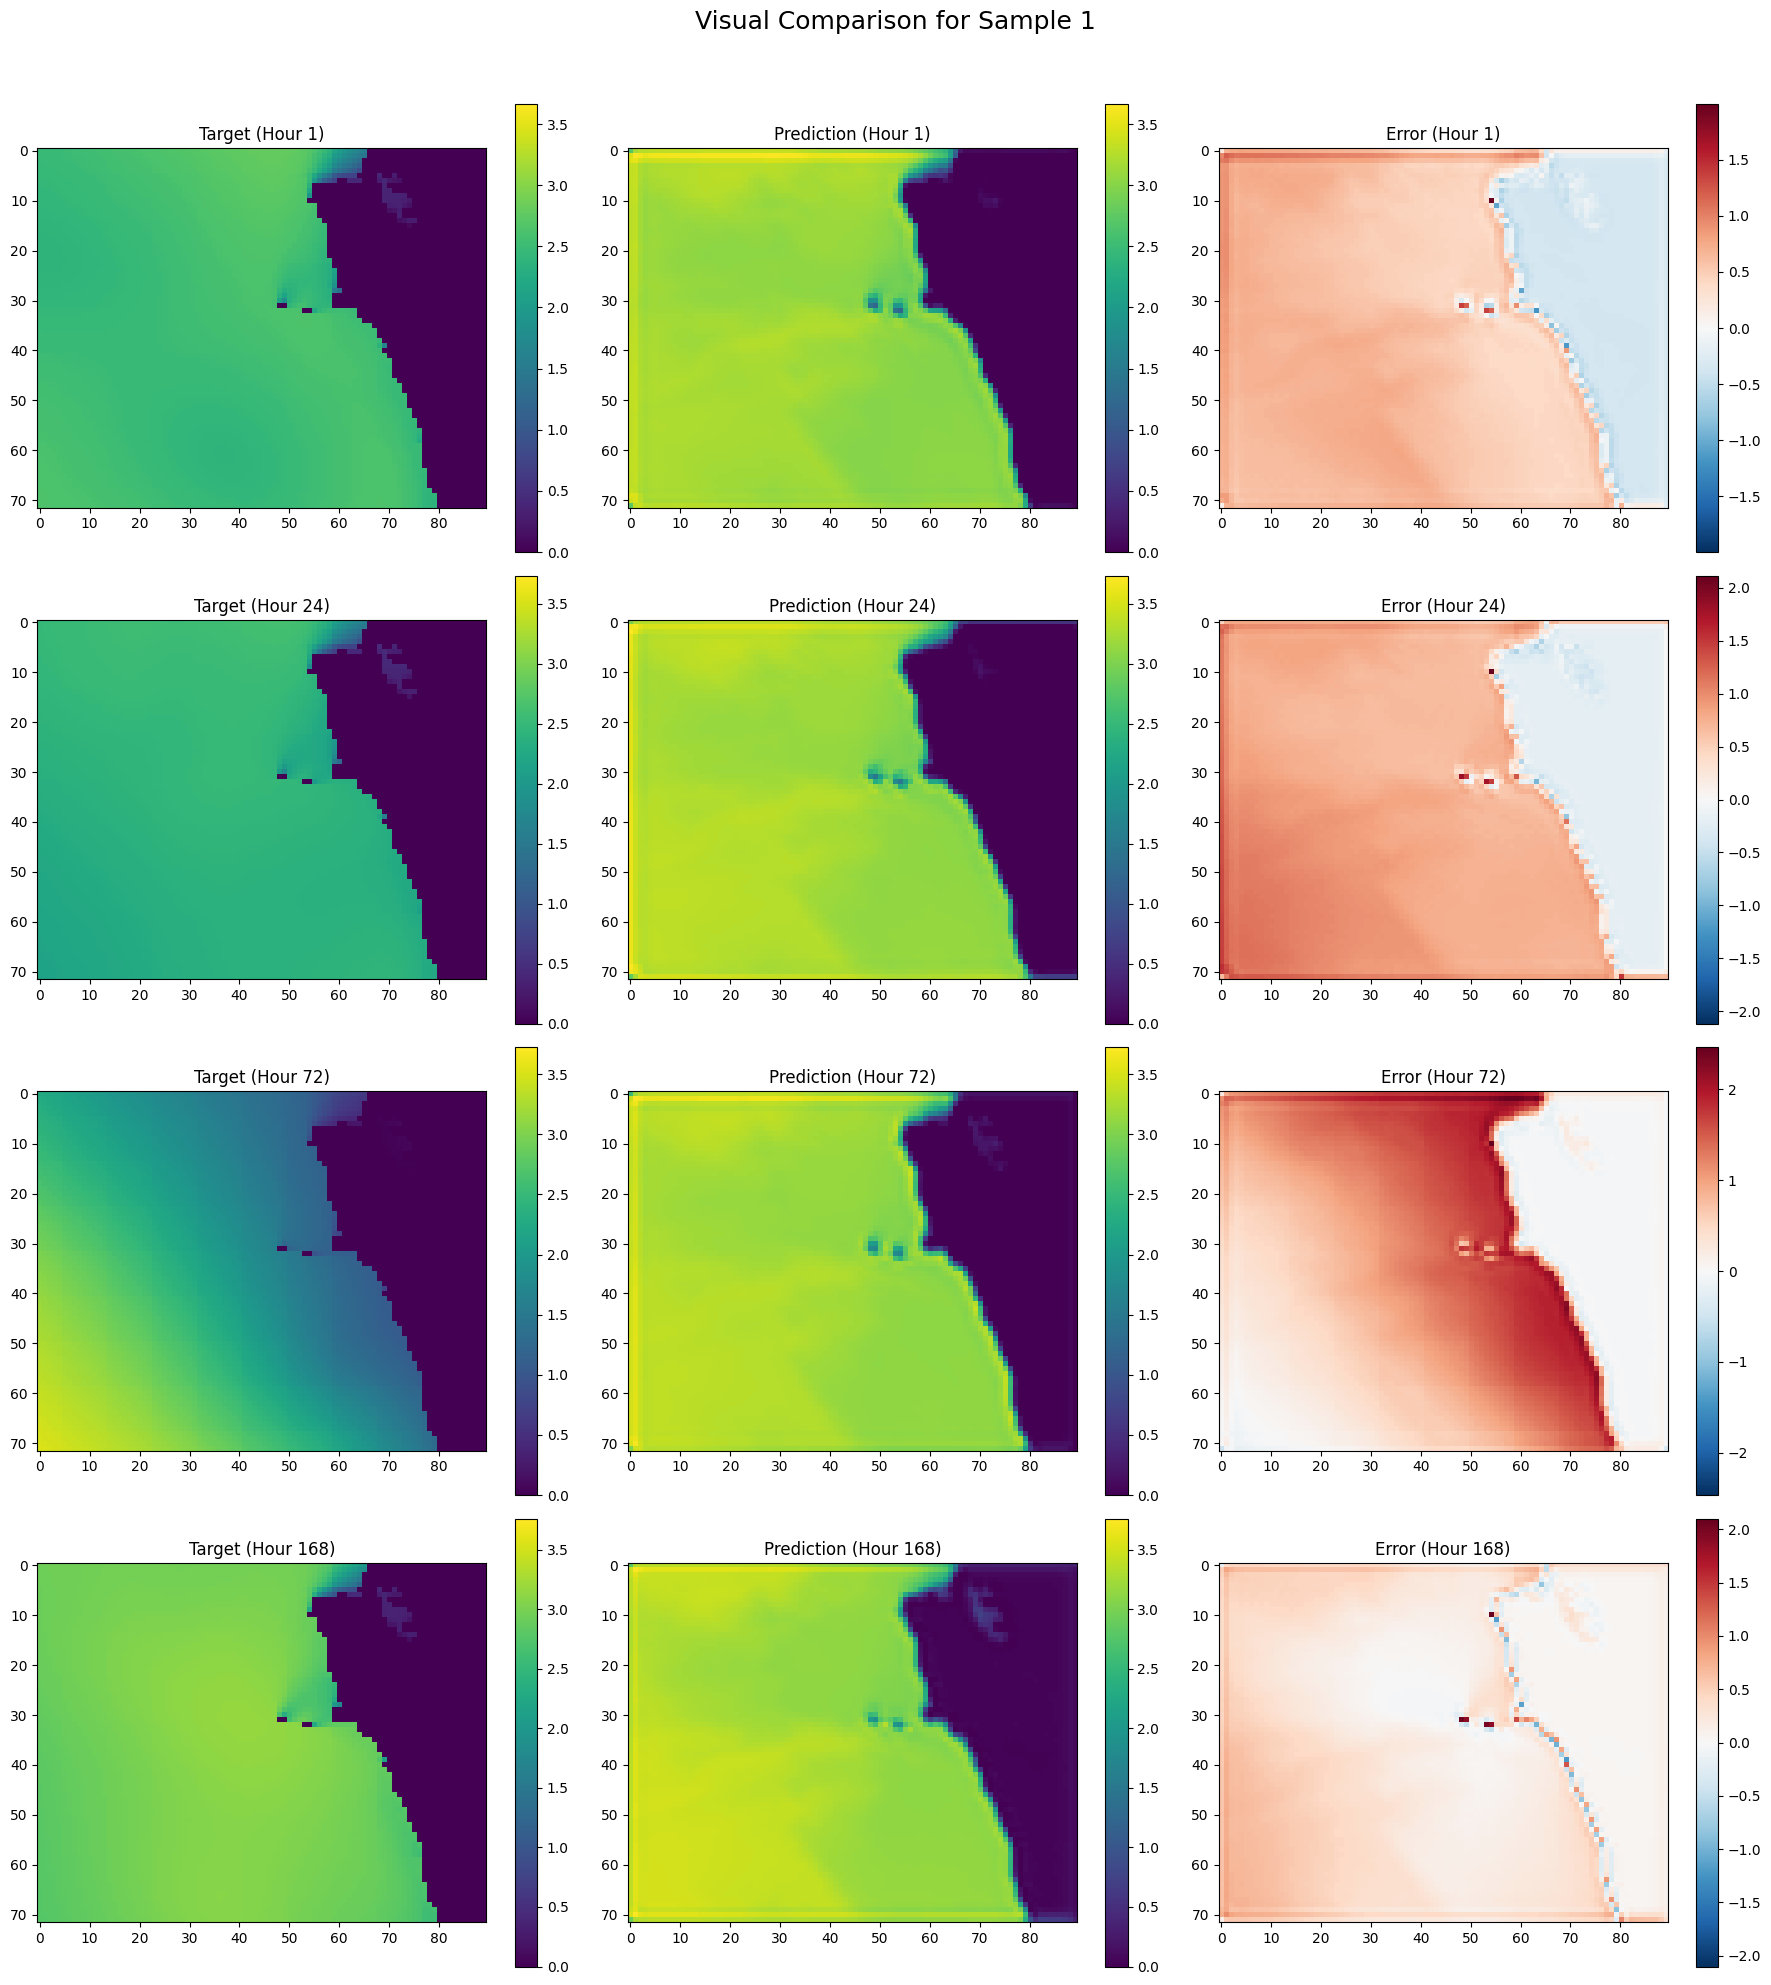

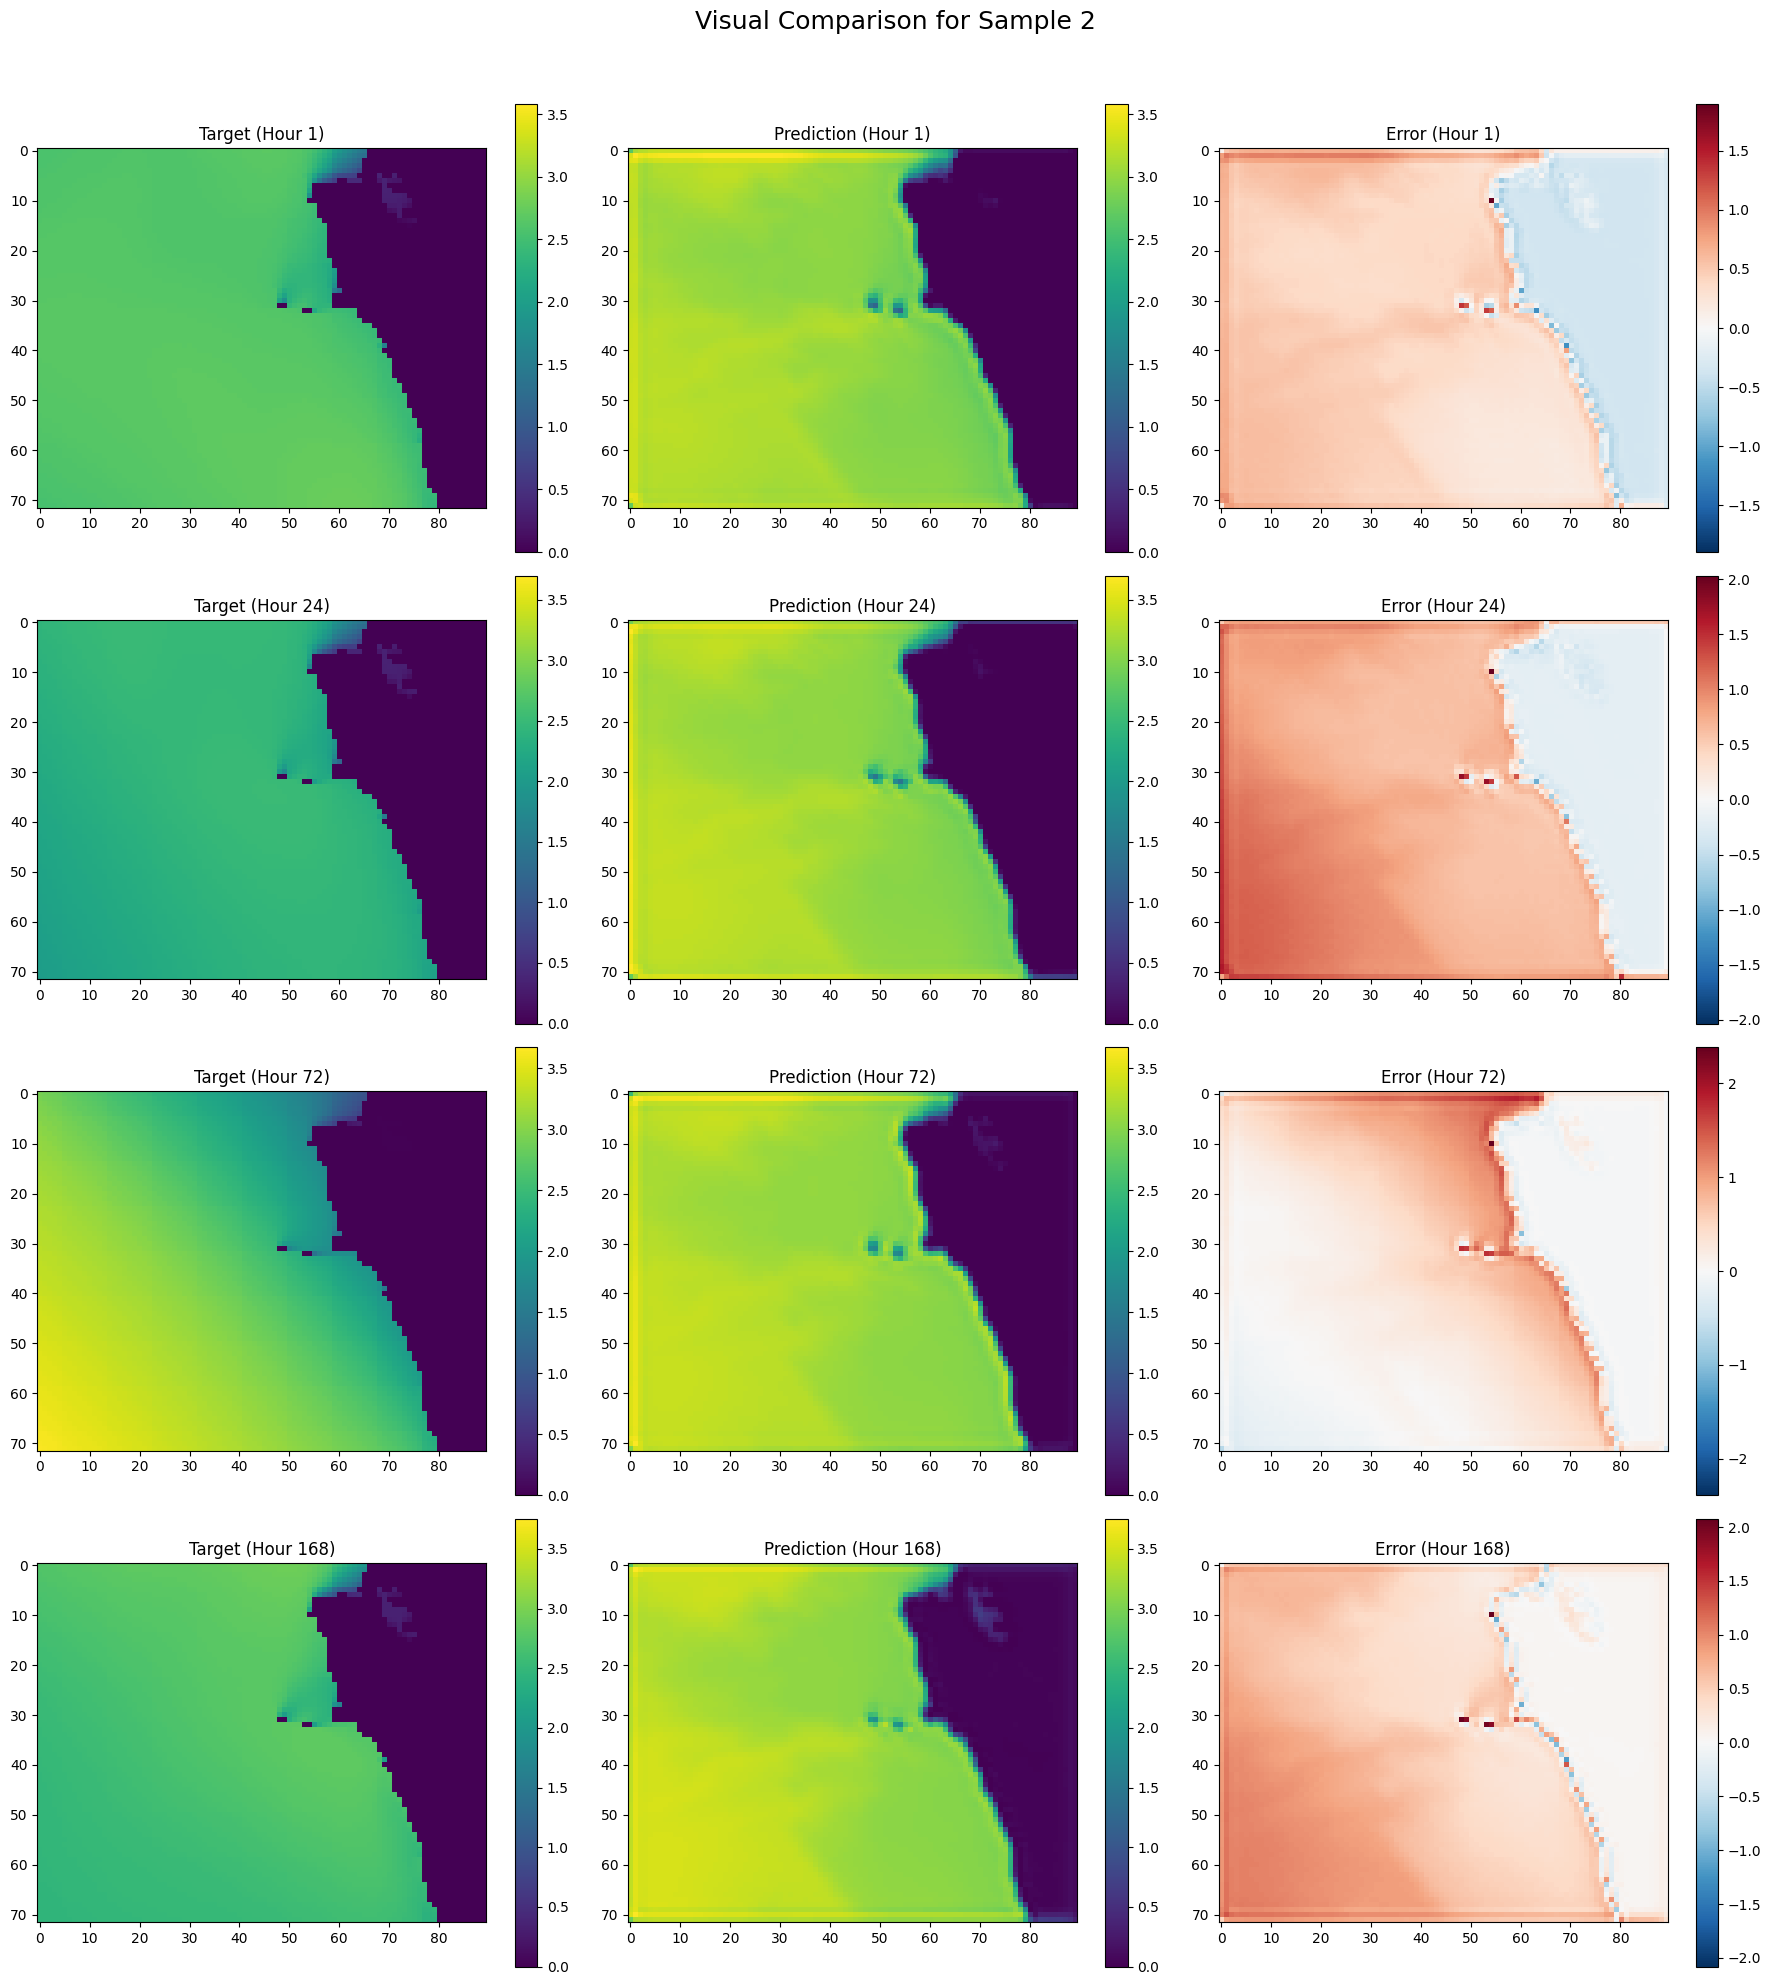


--- Generating Visualization: Scatter and Error Distribution Plots ---


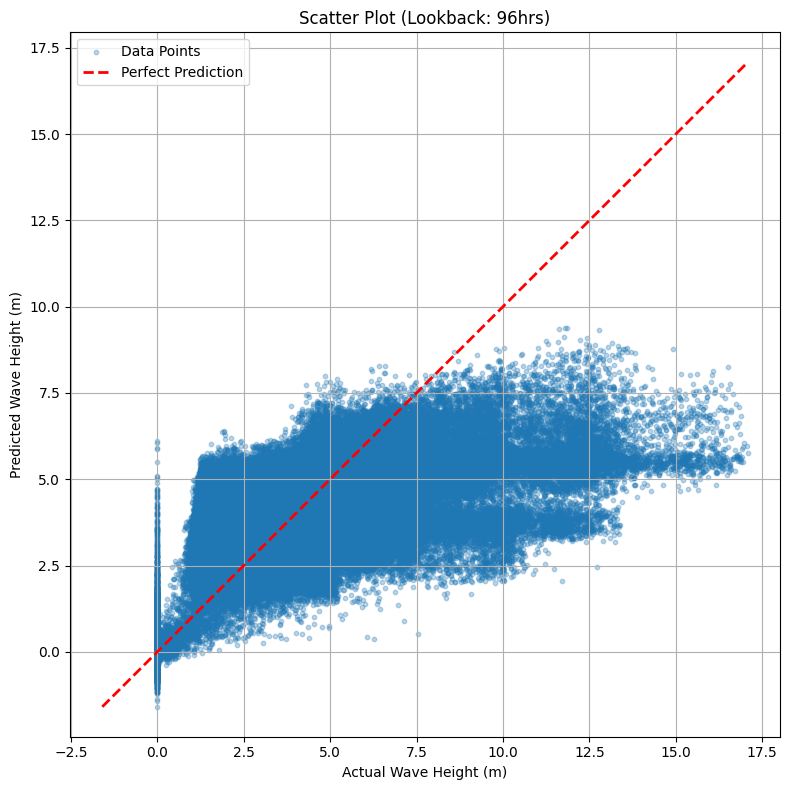

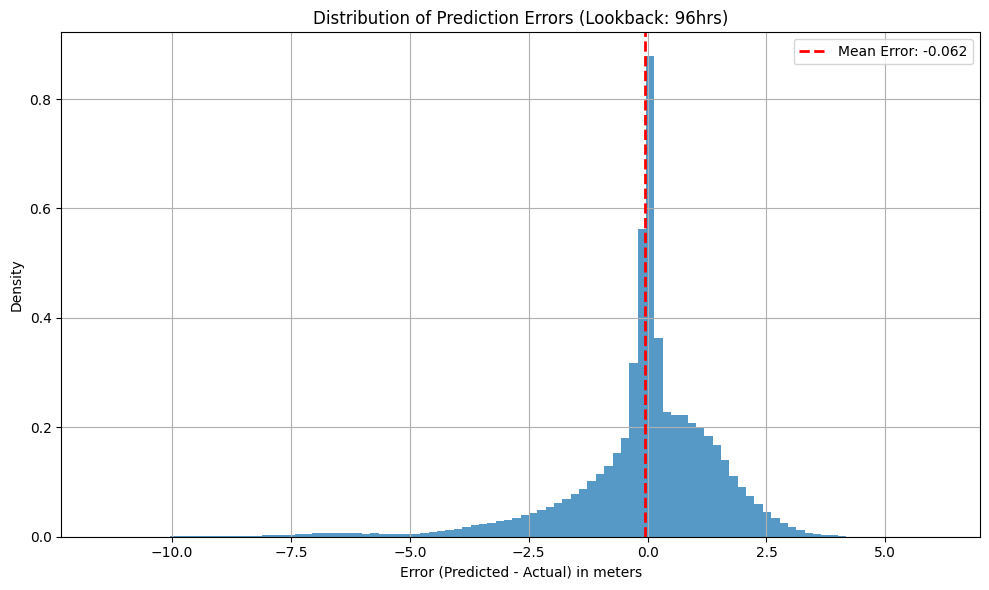


✅ All evaluation visualizations are complete.


In [5]:
# =============================================================================
# STEP 3, PART 2: VISUALIZATION PLOTS
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np

# --- Visualization Functions ---
def plot_visual_comparison(vis_data, timesteps_to_plot):
    print("\n--- Generating Visualization: Comparison Maps ---")
    num_timesteps = len(timesteps_to_plot)
    for i in range(len(vis_data['predictions'])): # Loop through the 2 samples we stored
        fig, axes = plt.subplots(num_timesteps, 3, figsize=(18, 5 * num_timesteps), squeeze=False)
        plt.suptitle(f"Visual Comparison for Sample {i+1}", fontsize=18, y=0.99)
        for row, t_idx in enumerate(timesteps_to_plot):
            pred_s, targ_s = vis_data['predictions'][i][t_idx], vis_data['targets'][i][t_idx]
            v_max = max(np.max(pred_s), np.max(targ_s), 0.1)
            
            im1 = axes[row, 0].imshow(targ_s, cmap='viridis', vmin=0, vmax=v_max)
            fig.colorbar(im1, ax=axes[row, 0])
            axes[row, 0].set_title(f'Target (Hour {t_idx+1})')
            
            im2 = axes[row, 1].imshow(pred_s, cmap='viridis', vmin=0, vmax=v_max)
            fig.colorbar(im2, ax=axes[row, 1])
            axes[row, 1].set_title(f'Prediction (Hour {t_idx+1})')
            
            diff = pred_s - targ_s
            diff_max = np.max(np.abs(diff)) if np.max(np.abs(diff)) > 0 else 0.1
            im3 = axes[row, 2].imshow(diff, cmap='RdBu_r', vmin=-diff_max, vmax=diff_max)
            fig.colorbar(im3, ax=axes[row, 2])
            axes[row, 2].set_title(f'Error (Hour {t_idx+1})')
            
        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()

def plot_timeseries_comparison(vis_data, forecast_horizon, lookback_hours, plot_type='mean'):
    agg_func = np.mean if plot_type == 'mean' else np.max
    agg_label = 'Average' if plot_type == 'mean' else 'Maximum'

    print(f"\n--- Generating Visualization: Spatially-{agg_label} Time Series ---")

    prediction_sample = vis_data['predictions'][0]
    target_sample = vis_data['targets'][0]

    pred_agg_over_time = agg_func(prediction_sample, axis=(1, 2))
    target_agg_over_time = agg_func(target_sample, axis=(1, 2))
    hours = np.arange(1, forecast_horizon + 1)

    plt.figure(figsize=(15, 7))
    plt.plot(hours, target_agg_over_time, 'b-', label=f'Actual (Spatially {agg_label})', marker='.')
    plt.plot(hours, pred_agg_over_time, 'r--', label=f'Predicted (Spatially {agg_label})', marker='.')
    plt.title(f"Time Series of Spatially-{agg_label} Wave Height (Lookback: {lookback_hours}hrs)")
    plt.xlabel("Forecast Hour")
    plt.ylabel(f"{agg_label} Wave Height (m)")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_hourly_error(hourly_rmse, hourly_mae, forecast_horizon, lookback_hours):
    print("\n--- Generating Visualization: Average Error per Forecast Hour ---")
    hours = np.arange(1, forecast_horizon + 1)
    fig, ax1 = plt.subplots(figsize=(15, 7))

    # Plot RMSE
    color1 = 'crimson'
    ax1.plot(hours, hourly_rmse, 'o-', color=color1, label='RMSE')
    ax1.set_xlabel('Forecast Hour')
    ax1.set_ylabel('RMSE (m)', color=color1)
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.legend(loc='upper left')
    
    # Create a second y-axis that shares the same x-axis
    ax2 = ax1.twinx()
    color2 = 'dodgerblue'
    ax2.plot(hours, hourly_mae, 's--', color=color2, label='MAE')
    ax2.set_ylabel('MAE (m)', color=color2)
    ax2.tick_params(axis='y', labelcolor=color2)
    ax2.legend(loc='upper right')

    plt.title(f'Average Error per Forecast Hour (Lookback: {lookback_hours}hrs)')
    plt.grid(True, linestyle='--', alpha=0.5)
    fig.tight_layout()
    plt.show()

# --- Generate All Visualizations ---
plot_timeseries_comparison(vis_data, FORECAST_HORIZON_HOURS, LOOKBACK_HOURS, plot_type='mean')
plot_timeseries_comparison(vis_data, FORECAST_HORIZON_HOURS, LOOKBACK_HOURS, plot_type='max')
plot_hourly_error(hourly_rmse, hourly_mae, FORECAST_HORIZON_HOURS, LOOKBACK_HOURS)
plot_visual_comparison(vis_data, timesteps_to_plot=[0, 23, 71, 167])

# --- Scatter and Error Distribution Plots ---
print("\n--- Generating Visualization: Scatter and Error Distribution Plots ---")
errors = all_preds_flat - all_targets_flat

# Scatter Plot
plt.figure(figsize=(8, 8))
plt.scatter(all_targets_flat, all_preds_flat, alpha=0.3, s=10, label='Data Points')
min_val = min(all_targets_flat.min(), all_preds_flat.min())
max_val = max(all_targets_flat.max(), all_preds_flat.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Wave Height (m)"); plt.ylabel("Predicted Wave Height (m)")
plt.title(f"Scatter Plot (Lookback: {LOOKBACK_HOURS}hrs)"); plt.grid(True); plt.legend()
plt.axis('equal'); plt.tight_layout(); plt.show()

# Error Histogram
mean_error = np.mean(errors)
plt.figure(figsize=(10, 6))
plt.hist(errors, bins=100, density=True, alpha=0.75)
plt.axvline(mean_error, color='r', linestyle='--', lw=2, label=f'Mean Error: {mean_error:.3f}')
plt.title(f"Distribution of Prediction Errors (Lookback: {LOOKBACK_HOURS}hrs)")
plt.xlabel("Error (Predicted - Actual) in meters"); plt.ylabel("Density")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

print("\n✅ All evaluation visualizations are complete.")